5 data pertama:
Jam belajar: 3.00 jam -> Nilai: 18.74
Jam belajar: 7.61 jam -> Nilai: 38.33
Jam belajar: 5.86 jam -> Nilai: 31.63
Jam belajar: 4.79 jam -> Nilai: 20.59
Jam belajar: 1.25 jam -> Nilai: 9.96

Persamaan regresi: Nilai = 5.43 + 4.35 × Jam Belajar
Artinya: Setiap tambahan 1 jam belajar, nilai naik sekitar 4.35 poin

MAE: 1.774
RMSE: 2.426
R²: 0.951


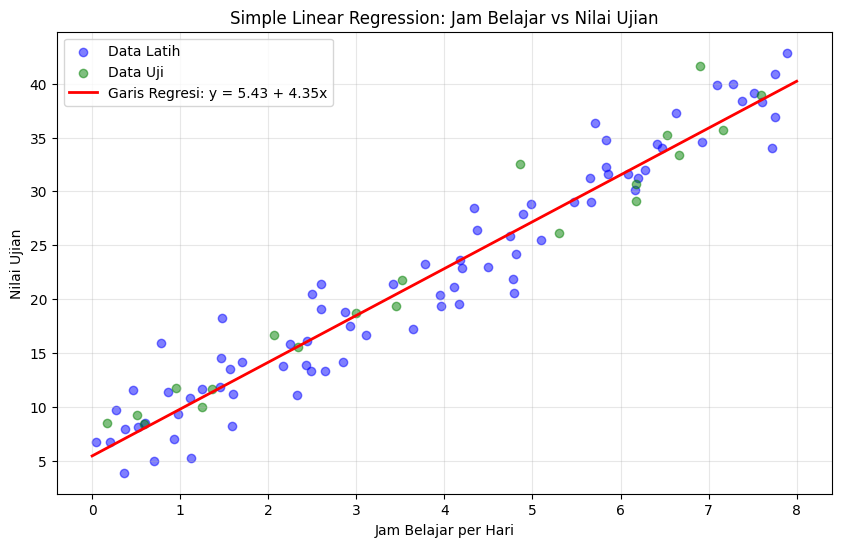

In [2]:
# TUGAS 1: Simple Linear Regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Membuat data sintetis: hubungan antara jam belajar (X) dan nilai ujian (y)
# Rumus: nilai = 5 + 4.5 * jam_belajar + noise
np.random.seed(42)
jam_belajar = np.random.rand(100, 1) * 8  # 0-8 jam belajar
nilai_ujian = 5 + 4.5 * jam_belajar[:, 0] + np.random.randn(100) * 3

print("5 data pertama:")
for i in range(5):
    print(f"Jam belajar: {jam_belajar[i][0]:.2f} jam -> Nilai: {nilai_ujian[i]:.2f}")

# Membagi data: 80% latih, 20% uji
X_train, X_test, y_train, y_test = train_test_split(jam_belajar, nilai_ujian, test_size=0.2, random_state=42)

# Melatih model regresi linear
model = LinearRegression()
model.fit(X_train, y_train)

# Memprediksi data uji
y_pred = model.predict(X_test)

# Menampilkan koefisien model
print(f"\nPersamaan regresi: Nilai = {model.intercept_:.2f} + {model.coef_[0]:.2f} × Jam Belajar")
print(f"Artinya: Setiap tambahan 1 jam belajar, nilai naik sekitar {model.coef_[0]:.2f} poin")

# Evaluasi model
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

# Visualisasi
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Data Latih')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Data Uji')

# Plot garis regresi
x_range = np.linspace(0, 8, 100).reshape(-1, 1)
y_range = model.predict(x_range)
plt.plot(x_range, y_range, color='red', linewidth=2, label=f'Garis Regresi: y = {model.intercept_:.2f} + {model.coef_[0]:.2f}x')

plt.xlabel('Jam Belajar per Hari')
plt.ylabel('Nilai Ujian')
plt.title('Simple Linear Regression: Jam Belajar vs Nilai Ujian')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# TUGAS 2: Multiple Linear Regression
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Membuat data sintetis untuk prediksi harga rumah
# Fitur: luas_tanah (m²), jumlah_kamar, jarak_ke_pusat_kota (km)
np.random.seed(42)
n_samples = 200

luas_tanah = np.random.randint(50, 200, n_samples)          # 50-200 m²
jumlah_kamar = np.random.randint(1, 6, n_samples)           # 1-5 kamar
jarak_ke_pusat = np.random.uniform(0.5, 15, n_samples)      # 0.5-15 km

# Rumus harga: 300 + 5*luas + 20*jumlah_kamar - 8*jarak + noise
harga_rumah = (300 + 5*luas_tanah + 20*jumlah_kamar - 8*jarak_ke_pusat 
               + np.random.randn(n_samples) * 30)

# Membuat DataFrame
df_rumah = pd.DataFrame({
    'Luas_Tanah': luas_tanah,
    'Jumlah_Kamar': jumlah_kamar,
    'Jarak_Pusat': jarak_ke_pusat,
    'Harga_Rumah': harga_rumah
})

print("5 data pertama:")
print(df_rumah.head())
print("\nStatistik deskriptif:")
print(df_rumah.describe().round(2))

# Menentukan fitur (X) dan target (y)
X = df_rumah[['Luas_Tanah', 'Jumlah_Kamar', 'Jarak_Pusat']]
y = df_rumah['Harga_Rumah']

# Membagi data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Melatih model multiple linear regression
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

# Prediksi
y_pred_multi = model_multi.predict(X_test)

# Menampilkan koefisien
print("\n=== HASIL MULTIPLE LINEAR REGRESSION ===")
print(f"Intercept: {model_multi.intercept_:.2f}")
for i, col in enumerate(X.columns):
    print(f"Koefisien {col}: {model_multi.coef_[i]:.2f}")

# Evaluasi
mae_multi = mean_absolute_error(y_test, y_pred_multi)
rmse_multi = root_mean_squared_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print(f"\nMAE: {mae_multi:.2f}")
print(f"RMSE: {rmse_multi:.2f}")
print(f"R²: {r2_multi:.3f}")

5 data pertama:
   Luas_Tanah  Jumlah_Kamar  Jarak_Pusat  Harga_Rumah
0         152             4     9.574969  1066.846094
1         142             1     7.795476  1014.174080
2          64             1    12.919103   541.746366
3         156             2    10.051058  1074.188894
4         121             2     2.862549   952.897002

Statistik deskriptif:
       Luas_Tanah  Jumlah_Kamar  Jarak_Pusat  Harga_Rumah
count      200.00        200.00       200.00       200.00
mean       126.75          2.98         8.30       925.98
std         43.52          1.45         4.50       226.43
min         50.00          1.00         0.66       498.71
25%         90.00          2.00         4.59       722.14
50%        130.50          3.00         8.83       950.45
75%        165.25          4.00        12.30      1111.72
max        199.00          5.00        15.00      1382.59

=== HASIL MULTIPLE LINEAR REGRESSION ===
Intercept: 283.14
Koefisien Luas_Tanah: 5.09
Koefisien Jumlah_Kamar: 21.1

PERBANDINGAN DEGREE 1 VS DEGREE 2

--- MODEL DEGREE 1 (Linear) ---
MAE  : 4.640
RMSE : 5.671
R²   : 0.456

--- MODEL DEGREE 2 (Polynomial) ---
MAE  : 1.763
RMSE : 2.066
R²   : 0.928

--- KOEFISIEN POLYNOMIAL DEGREE 2 ---
Intercept : 5.216
Koefisien x  : 3.146
Koefisien x² : 2.036

Persamaan: y = 5.216 + 3.146x + 2.036x²


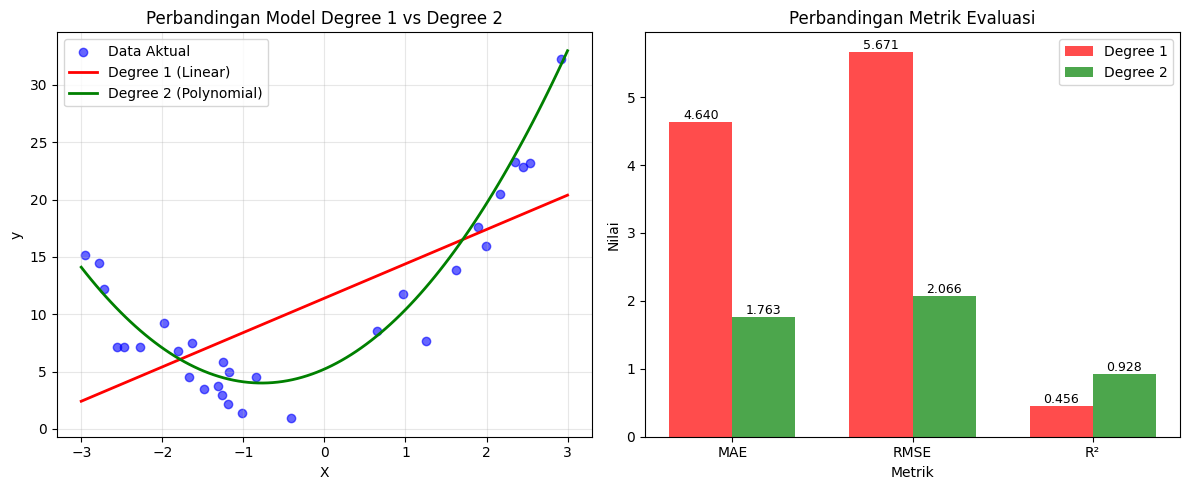

In [4]:
# TUGAS 3: Perbandingan Polynomial Regression Degree 1 vs Degree 2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Membuat data non-linear: y = 2x² + 3x + 5 + noise
np.random.seed(42)
X_poly = np.random.rand(150, 1) * 6 - 3  # rentang -3 sampai 3
y_poly = 2 * X_poly[:, 0]**2 + 3 * X_poly[:, 0] + 5 + np.random.randn(150) * 3

# Membagi data
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

# Model 1: Linear Regression (Degree 1)
model_deg1 = LinearRegression()
model_deg1.fit(X_train_p, y_train_p)
y_pred_deg1 = model_deg1.predict(X_test_p)

# Model 2: Polynomial Regression (Degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_p)
X_test_poly = poly.transform(X_test_p)

model_deg2 = LinearRegression()
model_deg2.fit(X_train_poly, y_train_p)
y_pred_deg2 = model_deg2.predict(X_test_poly)

# Evaluasi kedua model
mae_deg1 = mean_absolute_error(y_test_p, y_pred_deg1)
rmse_deg1 = root_mean_squared_error(y_test_p, y_pred_deg1)
r2_deg1 = r2_score(y_test_p, y_pred_deg1)

mae_deg2 = mean_absolute_error(y_test_p, y_pred_deg2)
rmse_deg2 = root_mean_squared_error(y_test_p, y_pred_deg2)
r2_deg2 = r2_score(y_test_p, y_pred_deg2)

print("="*60)
print("PERBANDINGAN DEGREE 1 VS DEGREE 2")
print("="*60)
print("\n--- MODEL DEGREE 1 (Linear) ---")
print(f"MAE  : {mae_deg1:.3f}")
print(f"RMSE : {rmse_deg1:.3f}")
print(f"R²   : {r2_deg1:.3f}")

print("\n--- MODEL DEGREE 2 (Polynomial) ---")
print(f"MAE  : {mae_deg2:.3f}")
print(f"RMSE : {rmse_deg2:.3f}")
print(f"R²   : {r2_deg2:.3f}")

# Menampilkan koefisien polynomial
print("\n--- KOEFISIEN POLYNOMIAL DEGREE 2 ---")
print(f"Intercept : {model_deg2.intercept_:.3f}")
print(f"Koefisien x  : {model_deg2.coef_[0]:.3f}")
print(f"Koefisien x² : {model_deg2.coef_[1]:.3f}")
print(f"\nPersamaan: y = {model_deg2.intercept_:.3f} + {model_deg2.coef_[0]:.3f}x + {model_deg2.coef_[1]:.3f}x²")

# Visualisasi perbandingan
plt.figure(figsize=(12, 5))

# Plot 1: Data dan kedua model
plt.subplot(1, 2, 1)
plt.scatter(X_test_p, y_test_p, color='blue', alpha=0.6, label='Data Aktual')

# Buat garis halus untuk plot
X_smooth = np.linspace(-3, 3, 100).reshape(-1, 1)
X_smooth_poly = poly.transform(X_smooth)

y_smooth_deg1 = model_deg1.predict(X_smooth)
y_smooth_deg2 = model_deg2.predict(X_smooth_poly)

plt.plot(X_smooth, y_smooth_deg1, color='red', linewidth=2, label='Degree 1 (Linear)')
plt.plot(X_smooth, y_smooth_deg2, color='green', linewidth=2, label='Degree 2 (Polynomial)')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Perbandingan Model Degree 1 vs Degree 2')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Bar chart metrik evaluasi
plt.subplot(1, 2, 2)
metrics = ['MAE', 'RMSE', 'R²']
deg1_values = [mae_deg1, rmse_deg1, r2_deg1]
deg2_values = [mae_deg2, rmse_deg2, r2_deg2]

x_pos = np.arange(len(metrics))
width = 0.35

bars1 = plt.bar(x_pos - width/2, deg1_values, width, label='Degree 1', color='red', alpha=0.7)
bars2 = plt.bar(x_pos + width/2, deg2_values, width, label='Degree 2', color='green', alpha=0.7)

plt.xlabel('Metrik')
plt.ylabel('Nilai')
plt.title('Perbandingan Metrik Evaluasi')
plt.xticks(x_pos, metrics)
plt.legend()

# Tambah nilai di atas bar
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()